In [1]:
print("Notebook Working Successfully")

Notebook Working Successfully


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

LOADING ACN DATA

In [3]:
import os
print(os.getcwd())

c:\Users\saeek\Downloads\socbiz\notebooks


In [4]:
import os
os.chdir(r"C:\Users\saeek\Downloads\socbiz")

In [5]:
acn_df = pd.read_excel("data/acndata_sessions.json.xlsx")

In [6]:
acn_df.to_csv(
    "data/acn_clean.csv",
    index=False
)

In [7]:
acn_df = pd.read_csv(
    "data/acn_clean.csv"
)


In [8]:
acn_df.head()

,_meta,end,min_kWh,site,start,_items,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID.1
0,NaN,NaN,NaN,caltech,NaN,NaN,5bc90cb9f9af8b0d7fe77cd2,39.0,"Wed, 25 Apr 2018 11:08:04 GMT","Wed, 25 Apr 2018 13:20:10 GMT","Wed, 25 Apr 2018 13:21:10 GMT",7.932,2_39_78_362_2018-04-25 11:08:04.400812,2.0,CA-496,2-39-78-362,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd3,39.0,"Wed, 25 Apr 2018 13:45:10 GMT","Thu, 26 Apr 2018 00:56:16 GMT","Wed, 25 Apr 2018 16:44:15 GMT",10.013,2_39_95_27_2018-04-25 13:45:09.617470,2.0,CA-319,2-39-95-27,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd4,39.0,"Wed, 25 Apr 2018 13:45:50 GMT","Wed, 25 Apr 2018 23:04:45 GMT","Wed, 25 Apr 2018 14:51:44 GMT",5.257,2_39_79_380_2018-04-25 13:45:49.962001,2.0,CA-489,2-39-79-380,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd5,39.0,"Wed, 25 Apr 2018 14:37:06 GMT","Wed, 25 Apr 2018 23:55:34 GMT","Wed, 25 Apr 2018 16:05:22 GMT",5.177,2_39_79_379_2018-04-25 14:37:06.460772,2.0,CA-327,2-39-79-379,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd6,39.0,"Wed, 25 Apr 2018 14:40:34 GMT","Wed, 25 Apr 2018 23:03:12 GMT","Wed, 25 Apr 2018 17:40:30 GMT",10.119,2_39_79_381_2018-04-25 14:40:33.638896,2.0,CA-490,2-39-79-381,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
acn_df.shape

(16304, 27)

In [10]:
acn_df.columns.to_list()

['_meta',
 'end',
 'min_kWh',
 'site',
 'start',
 '_items',
 '_id',
 'clusterID',
 'connectionTime',
 'disconnectTime',
 'doneChargingTime',
 'kWhDelivered',
 'sessionID',
 'siteID',
 'spaceID',
 'stationID',
 'timezone',
 'userID',
 'userInputs',
 'WhPerMile',
 'kWhRequested',
 'milesRequested',
 'minutesAvailable',
 'modifiedAt',
 'paymentRequired',
 'requestedDeparture',
 'userID.1']

In [11]:
acn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16304 entries, 0 to 16303
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   _meta               0 non-null      float64
 1   end                 0 non-null      float64
 2   min_kWh             0 non-null      float64
 3   site                1 non-null      str    
 4   start               0 non-null      float64
 5   _items              0 non-null      float64
 6   _id                 14999 non-null  str    
 7   clusterID           14999 non-null  float64
 8   connectionTime      14999 non-null  str    
 9   disconnectTime      14999 non-null  str    
 10  doneChargingTime    14991 non-null  str    
 11  kWhDelivered        14999 non-null  float64
 12  sessionID           14999 non-null  str    
 13  siteID              14999 non-null  float64
 14  spaceID             14999 non-null  str    
 15  stationID           14999 non-null  str    
 16  timezone       

In [12]:
KEEP = [
    "sessionID",        
    "stationID",       
    "siteID",         
    "clusterID",       
    "spaceID",          
    "connectionTime",  
    "disconnectTime",   
    "doneChargingTime", 
    "kWhDelivered",    
    "kWhRequested",     
]

In [13]:
acn_df=acn_df[KEEP].copy()

In [14]:
missing_value = acn_df.isnull().sum()
missing_value

sessionID            1305
stationID            1305
siteID               1305
clusterID            1305
spaceID              1305
connectionTime       1305
disconnectTime       1305
doneChargingTime     1313
kWhDelivered         1305
kWhRequested        12767
dtype: int64

In [15]:
duplicate_value = acn_df.duplicated().sum()
duplicate_value

np.int64(1075)

In [16]:
acn_df = acn_df.drop_duplicates()

In [17]:
duplicate_value = acn_df.duplicated().sum()
print(duplicate_value)
print("duplicate values removed")

0
duplicate values removed


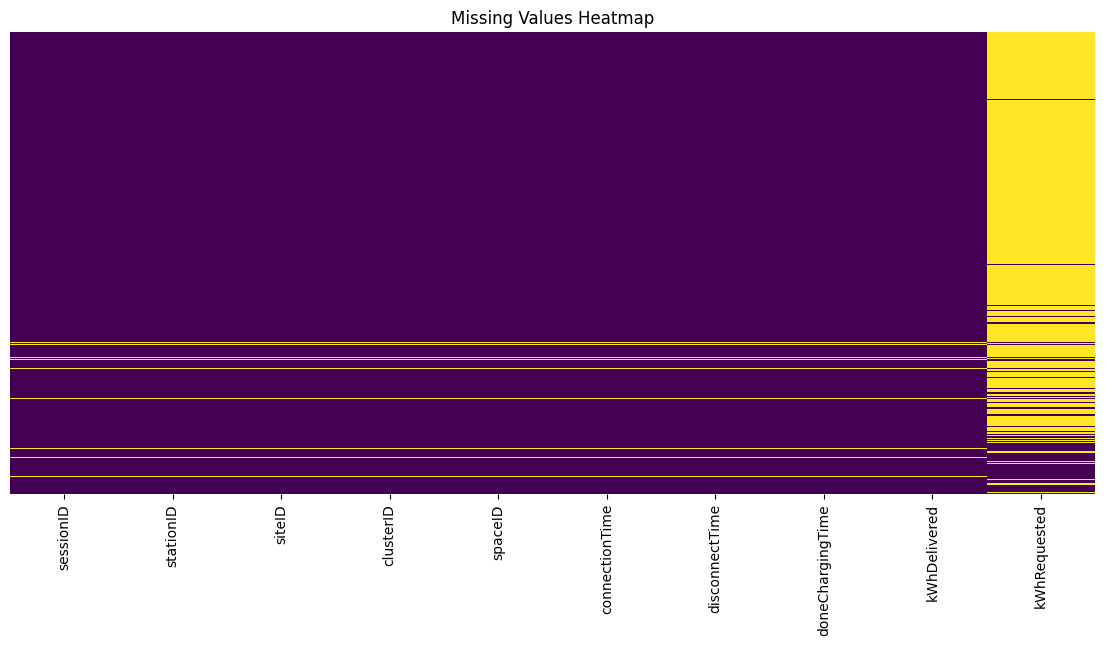

In [18]:
plt.figure(figsize=(14,6))

sns.heatmap(
    acn_df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

connectionTime,disconnectTime,kWhDelivered these values cannot be predicted,therefore we will drop the missing rows directly

In [19]:
critical_columns = [
    "connectionTime",
    "disconnectTime",
    "kWhDelivered"
]

acn_df = acn_df.dropna(
    subset=critical_columns
)

print("Remaining Rows:", len(acn_df))

Remaining Rows: 14999


donechargingtime is assumed to be equal to disconnecttime

In [20]:
acn_df["doneChargingTime"] = (

    acn_df["doneChargingTime"]

    .fillna(acn_df["disconnectTime"])
)

In [21]:
acn_df["kWhRequested"].skew()

np.float64(2.2413724248578806)

THE DATA IS SKEWED THEREFORE USE MEDAIN TO FILL MISSING VALUES

In [22]:
median_value = acn_df[ "kWhRequested"].median()

acn_df[ "kWhRequested"] = acn_df[ "kWhRequested"].fillna(
        median_value
    )

print(f"{ "kWhRequested"} median:", median_value)

kWhRequested median: 17.4


In [23]:
acn_df.isnull().sum()

sessionID           0
stationID           0
siteID              0
clusterID           0
spaceID             0
connectionTime      0
disconnectTime      0
doneChargingTime    0
kWhDelivered        0
kWhRequested        0
dtype: int64

ALL MISSING VALUES ARE RESOLVED

In [24]:
acn_df = acn_df.reset_index(drop=True)

In [25]:
acn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sessionID         14999 non-null  str    
 1   stationID         14999 non-null  str    
 2   siteID            14999 non-null  float64
 3   clusterID         14999 non-null  float64
 4   spaceID           14999 non-null  str    
 5   connectionTime    14999 non-null  str    
 6   disconnectTime    14999 non-null  str    
 7   doneChargingTime  14999 non-null  str    
 8   kWhDelivered      14999 non-null  float64
 9   kWhRequested      14999 non-null  float64
dtypes: float64(4), str(6)
memory usage: 3.2 MB


DATETIME FORMAT

In [26]:
acn_df["connectionTime"]    = pd.to_datetime(acn_df["connectionTime"],errors="coerce")
acn_df["disconnectTime"]    = pd.to_datetime(acn_df["disconnectTime"],errors="coerce")
acn_df["doneChargingTime"]  = pd.to_datetime(acn_df["doneChargingTime"], errors="coerce")
 

acn_df = acn_df.dropna(subset=["connectionTime", "disconnectTime", "doneChargingTime"])
acn_df = acn_df.reset_index(drop=True)

FEATURE ENGINEERING

In [27]:
acn_df["session_duration_hours"] = ((acn_df["disconnectTime"]-acn_df["connectionTime"]).dt.total_seconds())/3600

In [28]:
acn_df["charging_duration_hours"] = (acn_df["doneChargingTime"]-acn_df["connectionTime"]).dt.total_seconds() / 3600

In [29]:
acn_df["idle_time_hours"] = (acn_df["session_duration_hours"]-acn_df["charging_duration_hours"])

In [30]:
acn_df = acn_df[acn_df["disconnectTime"] > acn_df["connectionTime"]]
 
acn_df = acn_df[acn_df["doneChargingTime"] >= acn_df["connectionTime"]]

acn_df = acn_df[acn_df["doneChargingTime"] <= acn_df["disconnectTime"]]
 
acn_df = acn_df[acn_df["kWhDelivered"] > 0]
 
acn_df = acn_df.reset_index(drop=True)

In [31]:
acn_df["avg_charging_rate"] = (

    acn_df["kWhDelivered"]

    / acn_df["charging_duration_hours"]
)

In [32]:
acn_df["hour"] = (
    acn_df["connectionTime"].dt.hour
)

acn_df["day_of_week"] = (
    acn_df["connectionTime"].dt.day_name()
)

acn_df["month"] = (
    acn_df["connectionTime"].dt.month
)

acn_df["is_weekend"] = (
    acn_df["connectionTime"].dt.weekday >= 5
)

In [33]:
def peak_label(hour):

    if 7 <= hour <= 10:
        return "Morning Peak"

    elif 17 <= hour <= 21:
        return "Evening Peak"

    else:
        return "Off-Peak"

acn_df["peak_period"] = (
    acn_df["hour"].apply(peak_label)
)

In [34]:
BASE_TARIFF = 15

acn_df["baseline_revenue"] = (

    acn_df["kWhDelivered"]

    * BASE_TARIFF
)

In [35]:
hourly_sessions = (

    acn_df.groupby("hour")

    .size()

    .reset_index(name="active_sessions")
)

MAX_CHARGERS = 50

hourly_sessions["congestion_score"] = (

    hourly_sessions["active_sessions"]

    / MAX_CHARGERS
)

hourly_sessions.head()

,hour,active_sessions,congestion_score
0,0,710,14.20
1,1,843,16.86
2,2,691,13.82
3,3,546,10.92
4,4,356,7.12


DEALING WITH OUTLIERS

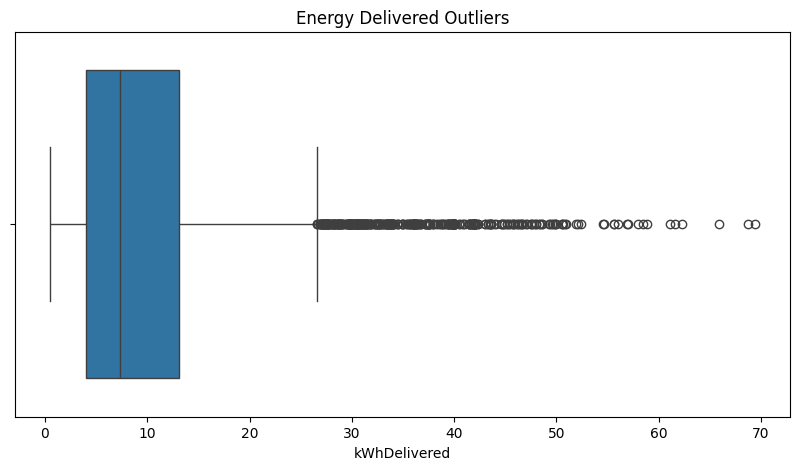

In [36]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=acn_df["kWhDelivered"]
)

plt.title("Energy Delivered Outliers")

plt.show()

In [37]:
Q1 = acn_df["kWhDelivered"].quantile(0.25)

Q3 = acn_df["kWhDelivered"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

acn_df = acn_df[
    (acn_df["kWhDelivered"] >= lower)
    &
    (acn_df["kWhDelivered"] <= upper)
]

print(acn_df.shape)

(13827, 20)


In [38]:
acn_df.head()

,sessionID,stationID,siteID,clusterID,spaceID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,kWhRequested,session_duration_hours,charging_duration_hours,idle_time_hours,avg_charging_rate,hour,day_of_week,month,is_weekend,peak_period,baseline_revenue
0,2_39_95_27_2018-04-25 13:45:09.617470,2-39-95-27,2.0,39.0,CA-319,2018-04-25 13:45:10,2018-04-26 00:56:16,2018-04-25 16:44:15,10.013,17.4,11.185000,2.984722,8.200278,3.354751,13,Wednesday,4,False,Off-Peak,150.195
1,2_39_79_380_2018-04-25 13:45:49.962001,2-39-79-380,2.0,39.0,CA-489,2018-04-25 13:45:50,2018-04-25 23:04:45,2018-04-25 14:51:44,5.257,17.4,9.315278,1.098333,8.216944,4.786343,13,Wednesday,4,False,Off-Peak,78.855
2,2_39_79_379_2018-04-25 14:37:06.460772,2-39-79-379,2.0,39.0,CA-327,2018-04-25 14:37:06,2018-04-25 23:55:34,2018-04-25 16:05:22,5.177,17.4,9.307778,1.471111,7.836667,3.519109,14,Wednesday,4,False,Off-Peak,77.655
3,2_39_79_381_2018-04-25 14:40:33.638896,2-39-79-381,2.0,39.0,CA-490,2018-04-25 14:40:34,2018-04-25 23:03:12,2018-04-25 17:40:30,10.119,17.4,8.377222,2.998889,5.378333,3.374250,14,Wednesday,4,False,Off-Peak,151.785
4,2_39_139_28_2018-04-25 14:43:49.647430,2-39-139-28,2.0,39.0,CA-303,2018-04-25 14:43:50,2018-04-26 01:17:30,2018-04-25 16:18:28,7.910,17.4,10.561111,1.577222,8.983889,5.015146,14,Wednesday,4,False,Off-Peak,118.650


In [39]:
print(acn_df.columns.tolist())

['sessionID', 'stationID', 'siteID', 'clusterID', 'spaceID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'kWhRequested', 'session_duration_hours', 'charging_duration_hours', 'idle_time_hours', 'avg_charging_rate', 'hour', 'day_of_week', 'month', 'is_weekend', 'peak_period', 'baseline_revenue']


In [40]:
acn_df.shape

(13827, 20)

In [41]:
acn_df.to_csv(
    "acn_cleaned_processed.csv",
    index=False
)

print("Clean Dataset Saved")

Clean Dataset Saved


THIS WAS ABOUT ACN DATASET NOW
NOW LETS WORK ON URBANEV DATASET